# How the tissue is arranged: spatial statistics and niches

Most of a spatial analysis answers *what is where* — which domain, which cell
type, which genes vary. This notebook covers the layer above that: **how the
things are arranged relative to each other**, and whether the arrangement means
anything.

Two namespaces:

| | |
|---|---|
| `ov.space.nb` | statistics over the spatial graph — who touches whom, how far the association reaches, whether a cluster is central or peripheral |
| `ov.space.niche` | recurrent multicellular structure — the same mix of cell types found in several places |

The niche section answers [issue #760](https://github.com/omicverse/omicverse/issues/760)
directly, including the part of it omicverse could already do under a different name.

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [2]:
import scanpy as sc
import squidpy as sq
import omicverse as ov

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


## The slide

A real 10x Visium section of mouse brain, with the cluster annotation that ships
with it. Everything below runs on this one object.

In [3]:
adata = sq.datasets.visium_hne_adata()
adata.obs['cell_type'] = adata.obs['cluster'].astype('category')
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster', 'cell_type'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
print(f"{adata.n_obs:,} spots, {adata.n_vars:,} genes, "
      f"{adata.obs['cell_type'].nunique()} annotated clusters")

2,688 spots, 18,078 genes, 15 annotated clusters


## The graph everything reads

Build it once. Every statistic below uses this graph, so the choices made here
propagate to all of them.

`coord_type='grid'` matters on an array platform. Plain k-nearest-neighbours
cannot know the slide has a lattice, so a spot on the rim of the tissue reaches
across the gap to fill its quota of 6 and acquires neighbours it does not touch.

In [5]:
ov.space.spatial_neighbors(adata, n_neighs=6, coord_type='grid')
graph = adata.obsp['spatial_connectivities']
degree = np.asarray((graph > 0).sum(axis=1)).ravel()
print(f"{graph.nnz:,} edges; node degree {degree.min()}-{degree.max()}, mean {degree.mean():.2f}")

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


Spatial neighbors: 2688 cells, 14756 connections (avg 5.5 neighbors/cell).
Stored in adata.obsp['spatial_connectivities'] and adata.obsp['spatial_distances'].
14,756 edges; node degree 1-6, mean 5.49


In [6]:
generic = adata.copy()
ov.space.spatial_neighbors(generic, n_neighs=6, coord_type='generic')
gd = np.asarray((generic.obsp['spatial_connectivities'] > 0).sum(axis=1)).ravel()
print(f"without the lattice gate: degree {gd.min()}-{gd.max()}, mean {gd.mean():.2f}")
print("a hexagonal lattice allows 6 — anything above that is a spot reaching across a gap")

Spatial neighbors: 2688 cells, 15244 connections (avg 5.7 neighbors/cell).
Stored in adata.obsp['spatial_connectivities'] and adata.obsp['spatial_distances'].
without the lattice gate: degree 5-8, mean 5.67
a hexagonal lattice allows 6 — anything above that is a spot reaching across a gap


## Who touches whom

`interaction_matrix` counts the edges between every pair of clusters. On its own
it mostly reflects how common each cluster is, which is what the enrichment test
below corrects for.

In [7]:
counts = ov.space.nb.interaction_matrix(adata, 'cell_type', copy=True)
labels = list(adata.obs['cell_type'].cat.categories)
pd.DataFrame(counts, index=labels, columns=labels).iloc[:5, :5]

,Cortex_1,Cortex_2,Cortex_3,Cortex_4,Cortex_5
Cortex_1,1284.0,1.0,137.0,121.0,4.0
Cortex_2,1.0,1228.0,62.0,9.0,82.0
Cortex_3,137.0,62.0,1076.0,0.0,2.0
Cortex_4,121.0,9.0,0.0,644.0,137.0
Cortex_5,4.0,82.0,2.0,137.0,328.0


`nhood_enrichment` reshuffles the cluster labels over the *fixed* graph a thousand
times and asks how far the observed contact count sits from that null. Holding the
geometry constant and permuting only the labelling is what makes the answer about
the biology rather than about the shape of the section.

In [8]:
ov.space.nb.enrichment(adata, 'cell_type', n_perms=1000, seed=0)
z = adata.uns['cell_type_nhood_enrichment']['zscore']
print(f"z-scores range {z.min():.1f} to {z.max():.1f}")

z-scores range -13.6 to 76.7


In [9]:
def enrichment_heatmap(matrix, names):
    fig, ax = plt.subplots(figsize=(7.5, 6.5))
    lim = np.abs(matrix).max()
    im = ax.imshow(matrix, cmap='RdBu_r', vmin=-lim, vmax=lim)
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=7)
    fig.colorbar(im, ax=ax, shrink=0.7, label='enrichment z-score')
    return ax

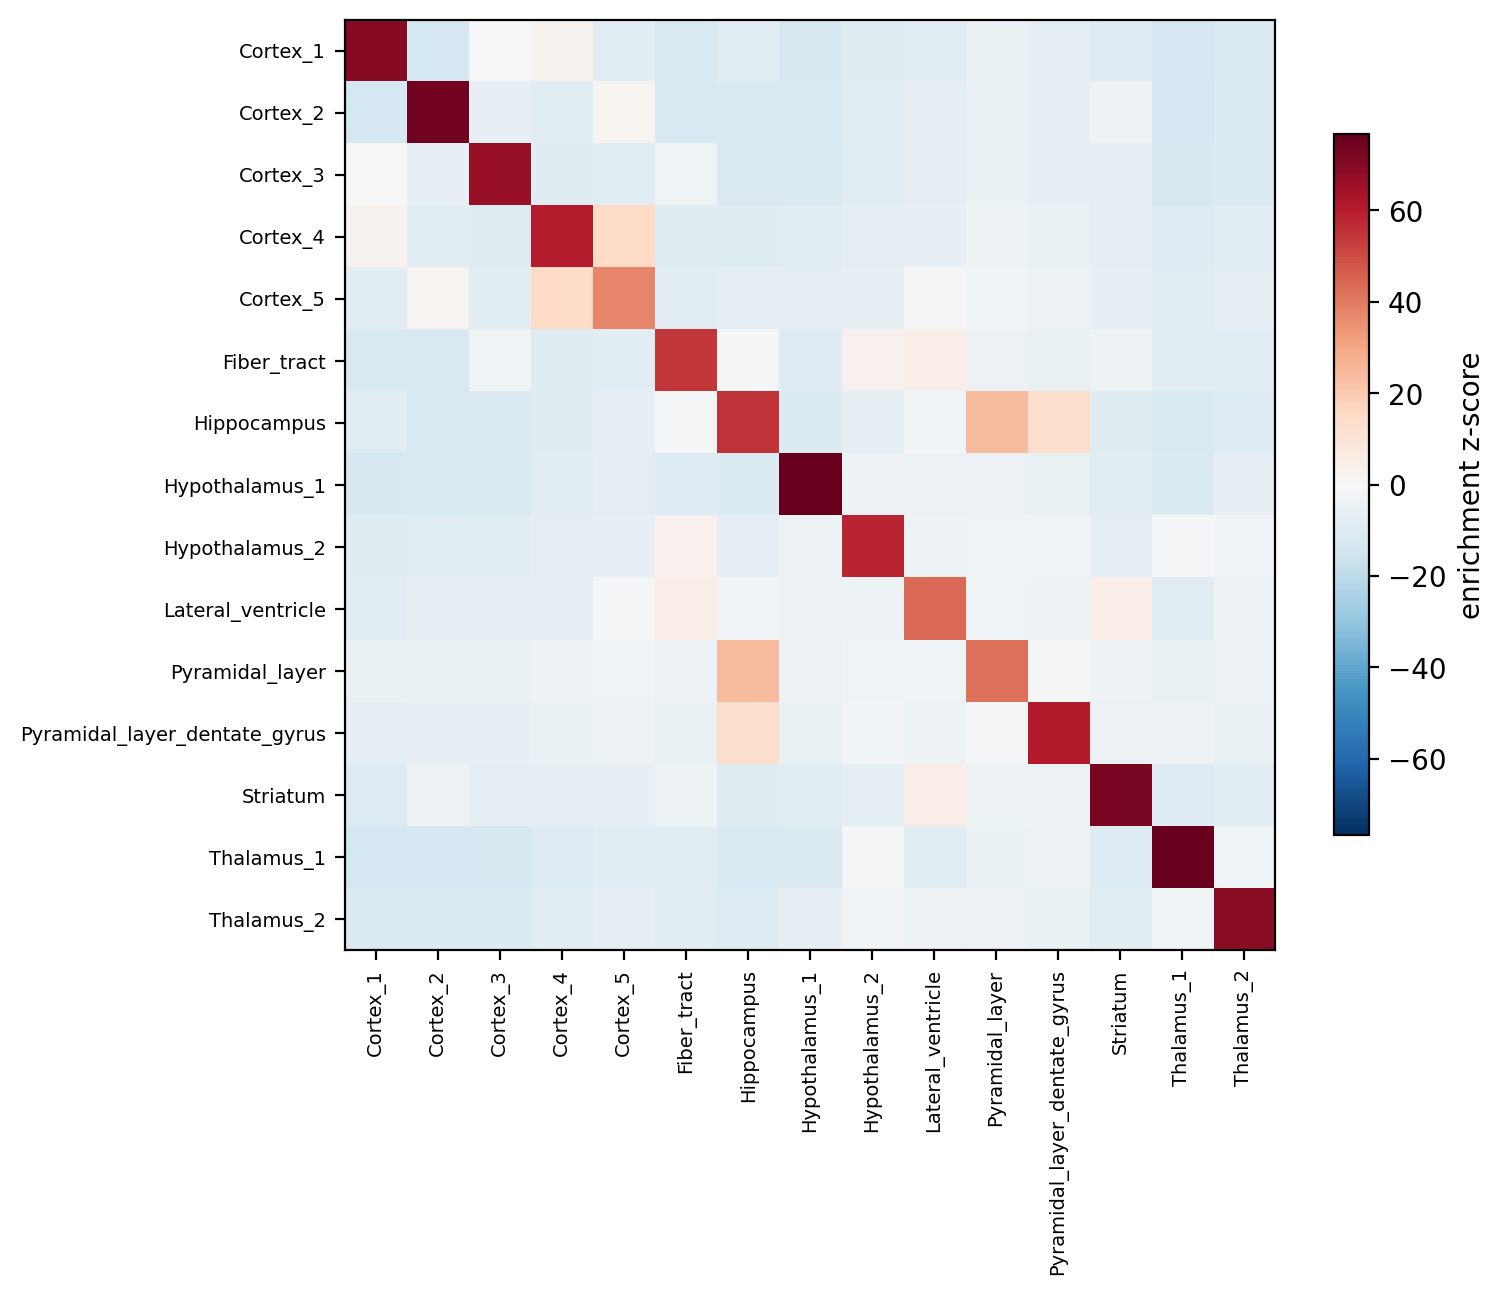

In [10]:
enrichment_heatmap(z, labels)
plt.show()

Red on the diagonal is the expected signature of spatially coherent domains: a
cluster touches itself far more than a random relabelling would allow. The
off-diagonal reds are the pairs that genuinely border each other.

In [11]:
pairs = [(labels[i], labels[j], z[i, j])
         for i in range(len(labels)) for j in range(i + 1, len(labels))]
top = sorted(pairs, key=lambda t: -t[2])[:5]
pd.DataFrame(top, columns=['cluster A', 'cluster B', 'z'])

,cluster A,cluster B,z
0,Hippocampus,Pyramidal_layer,24.205492
1,Cortex_4,Cortex_5,15.093635
2,Hippocampus,Pyramidal_layer_dentate_gyrus,13.534305
3,Fiber_tract,Lateral_ventricle,4.997356
4,Lateral_ventricle,Striatum,4.866170


## How far the association reaches

Adjacency is binary. `co_occurrence` asks the same question over a range of radii:
at each distance, how much more likely is cluster B nearby than it would be
anywhere on the slide. The distance at which the curve returns to 1 is the range
over which the association holds.

In [12]:
occ, radii = ov.space.nb.co_occurrence(adata, 'cell_type', interval=25, copy=True)
print(f"occurrence array {occ.shape} = (condition, target, radius); {len(radii)} radius edges")

occurrence array (15, 15, 24) = (condition, target, radius); 25 radius edges


In [13]:
def cooccurrence_curves(occ, radii, names, focus):
    i = names.index(focus)
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    for j, name in enumerate(names):
        ax.plot(radii[1:], occ[i, j, :], lw=1.6, label=name)
    ax.axhline(1.0, color='k', ls='--', lw=1)
    ax.set_xlabel('radius')
    ax.set_ylabel(f'p(cluster | {focus}) / p(cluster)')
    ax.legend(fontsize=6, ncol=2)
    return ax

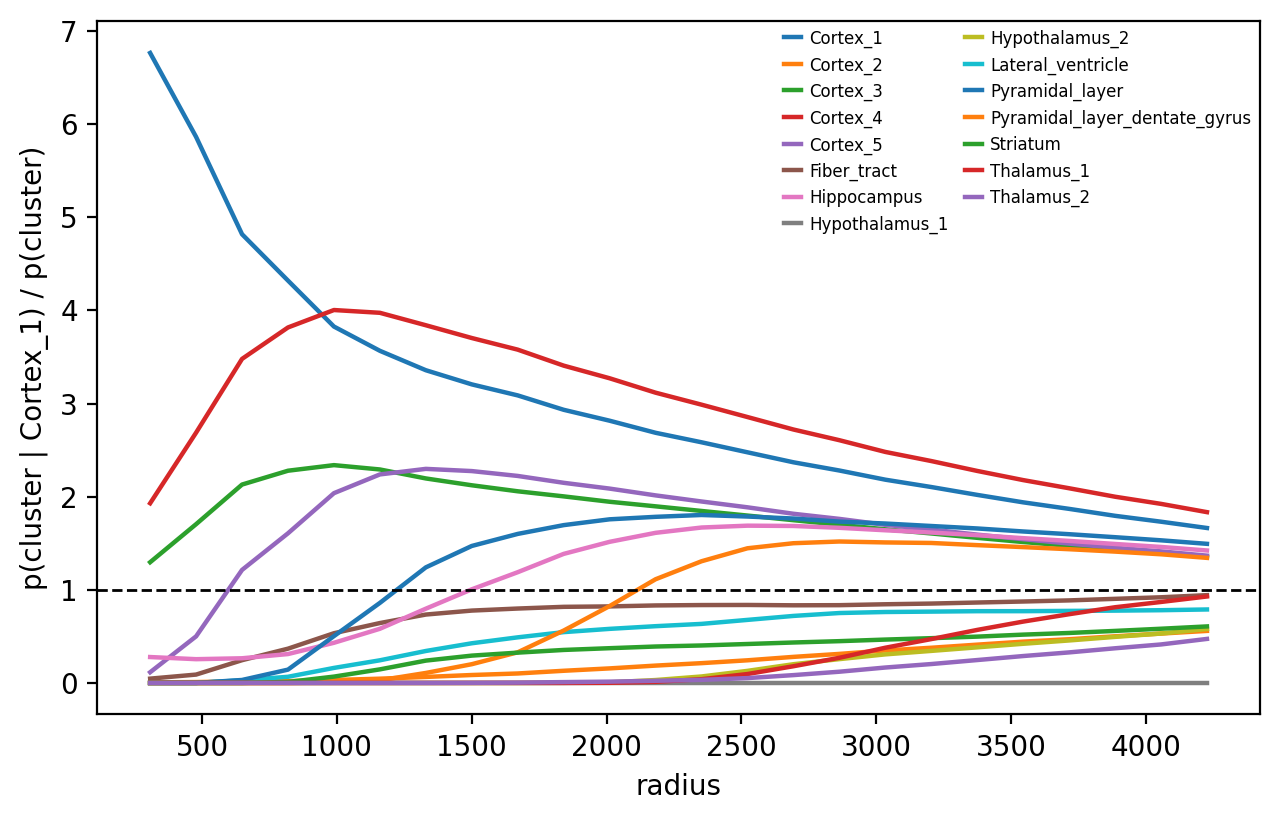

In [14]:
cooccurrence_curves(occ, radii, labels, labels[0])
plt.show()

## Is a cluster central or peripheral

These are *group* centralities: properties of a cluster as a set of nodes inside
the whole tissue graph, not of the cluster's own subgraph. A cluster can be
internally fragmented and still be highly central, because centrality is about its
relationship to everything else.

In [15]:
central = ov.space.nb.centrality(adata, 'cell_type', copy=True)
central.sort_values('closeness_centrality', ascending=False).head(6)

,degree_centrality,average_clustering,closeness_centrality
cell_type,,,
Fiber_tract,0.105199,0.375074,0.163198
Lateral_ventricle,0.056523,0.429841,0.130198
Hypothalamus_2,0.053620,0.370677,0.092245
Cortex_5,0.057054,0.479845,0.087715
Cortex_3,0.063830,0.373634,0.076066
Thalamus_1,0.035847,0.371903,0.073621


## Clustered, dispersed, or just random

Ripley's statistics compare a cluster's point pattern against points scattered
uniformly inside the tissue outline. Above the null band means clustered, below
means dispersed, inside means indistinguishable from random.

In [16]:
res = ov.space.nb.ripley(adata, 'cell_type', mode='L', n_simulations=50,
                         n_steps=40, seed=0, copy=True)
obs, sims = res['L_stat'], res['sims_stat']
print(f"observed {obs.shape[0]} rows over {obs['bins'].nunique()} radii; "
      f"null from {sims['sim'].nunique()} simulations")

observed 600 rows over 40 radii; null from 50 simulations


In [17]:
def ripley_plot(obs, sims, names):
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    band = sims.groupby('bins')['stats'].quantile([0.025, 0.975]).unstack()
    ax.fill_between(band.index, band[0.025], band[0.975], color='0.85',
                    label='95% of random placements')
    for name in names:
        sub = obs[obs['cell_type'] == name].sort_values('bins')
        ax.plot(sub['bins'], sub['stats'], lw=1.5, label=name)
    ax.set_xlabel('radius'); ax.set_ylabel("Ripley's L")
    ax.legend(fontsize=7, ncol=2)
    return ax

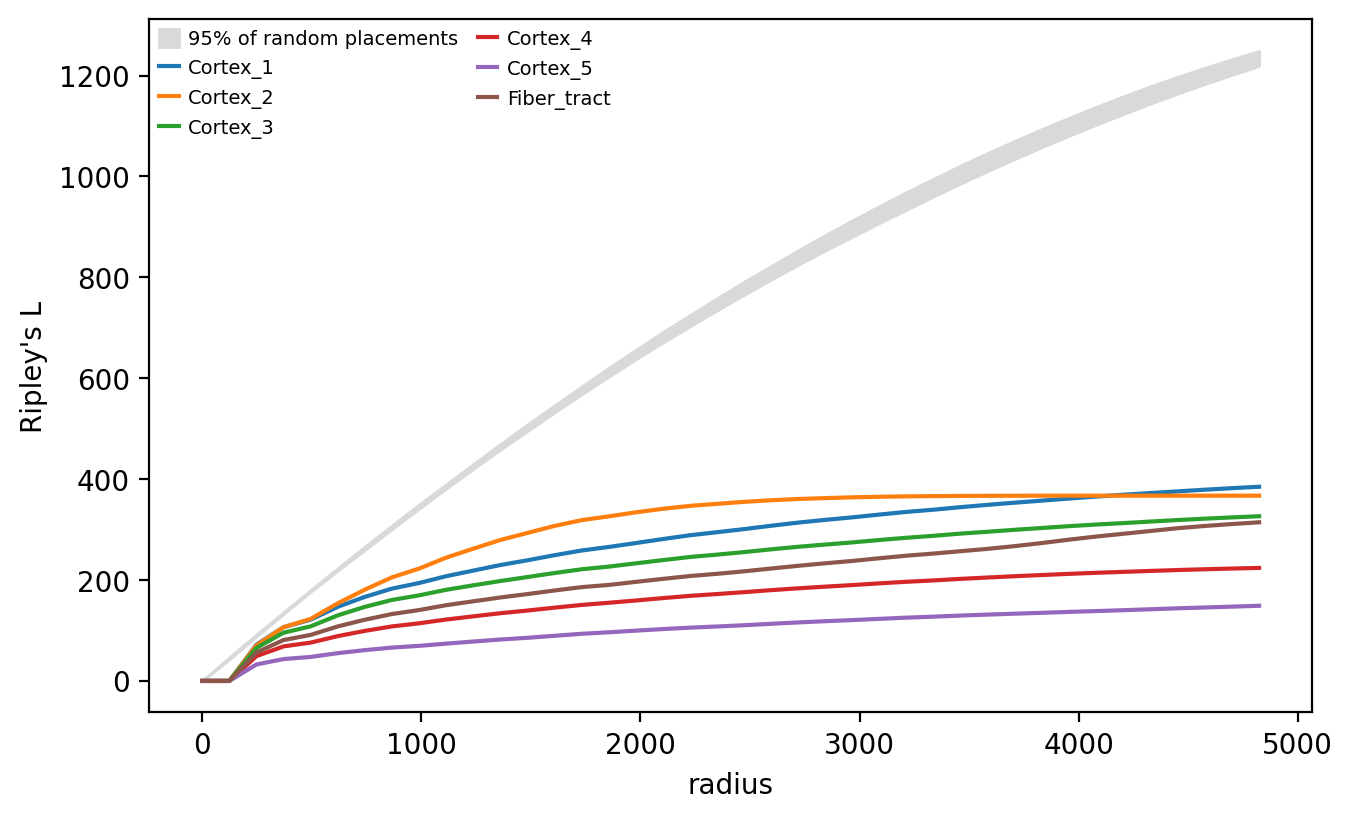

In [18]:
ripley_plot(obs, sims, labels[:6])
plt.show()

## Does a gene change with distance from something

`var_by_distance` turns "is this gene spatially variable" into the sharper
question "does it change as you move away from *that*". Distances are scaled to
[0, 1] per anchor so slides of different physical size are comparable; the
unscaled values are kept alongside in a `_raw` column.

In [19]:
anchor = str(adata.obs['cell_type'].value_counts().index[0])
ov.space.nb.var_by_distance(adata, groups=anchor, cluster_key='cell_type')
design = adata.obsm['design_matrix']
print(f"anchor cluster: {anchor}; columns {list(design.columns)}")
design.head(3)

anchor cluster: Cortex_1; columns ['Cortex_1_raw', 'Cortex_1']


,Cortex_1_raw,Cortex_1
AAACAAGTATCTCCCA-1,966.89865,0.144106
AAACAATCTACTAGCA-1,479.00000,0.071390
AAACACCAATAACTGC-1,5028.00000,0.749370


In [20]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
gene = adata.var_names[np.asarray(adata.X.sum(axis=0)).ravel().argmax()]

In [21]:
d = design[anchor].to_numpy()
expr = np.asarray(adata[:, gene].X.todense()).ravel()
keep = np.isfinite(d)
print(f'{keep.sum()} spots have a finite distance to {anchor}')

2404 spots have a finite distance to Cortex_1


In [22]:
def distance_profile(distance, values, xlabel, ylabel, n_bins=20):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.scatter(distance, values, s=4, alpha=0.3, c='0.6')
    edges = np.linspace(0, 1, n_bins + 1)
    which = np.digitize(distance, edges) - 1
    means = [values[which == b].mean() if (which == b).any() else np.nan
             for b in range(n_bins)]
    ax.plot(edges[:-1] + 0.5 / n_bins, means, lw=2.5, c='crimson')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    return ax

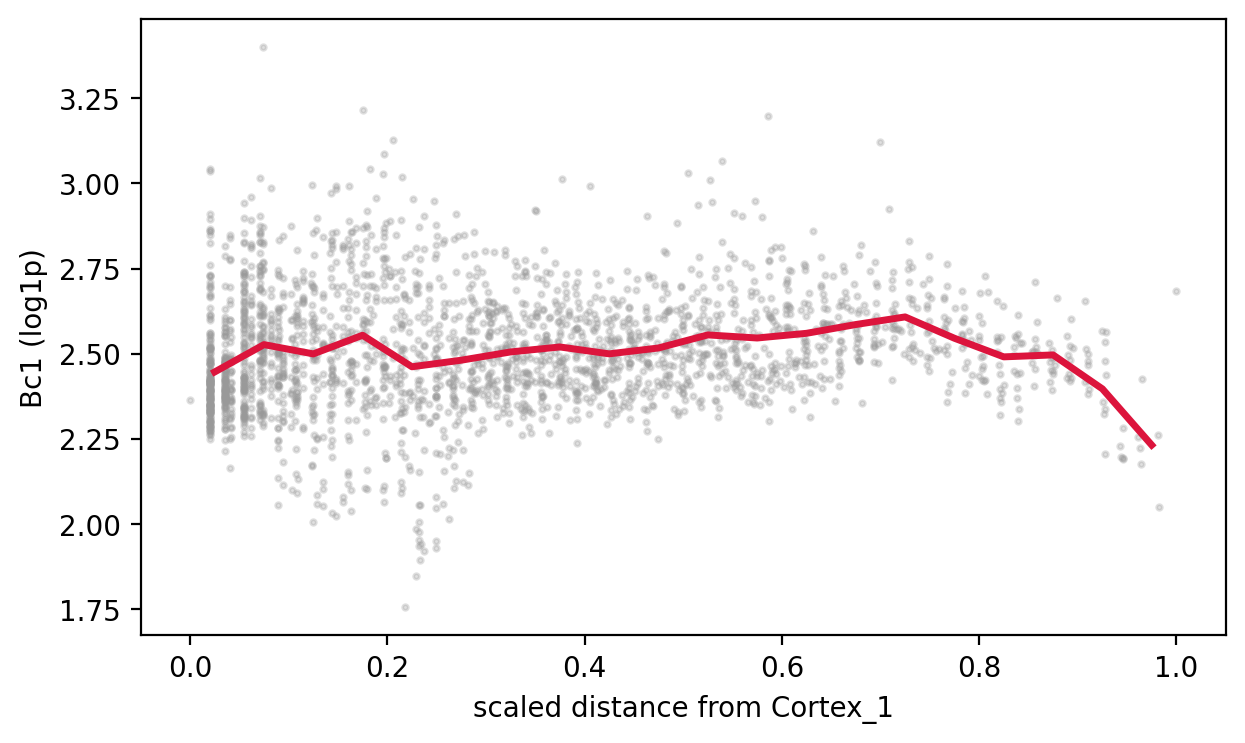

In [23]:
distance_profile(d[keep], expr[keep],
                 f'scaled distance from {anchor}', f'{gene} (log1p)')
plt.show()

## Niches

A niche is a composition that repeats. Issue #760 asked for three flavours and
they turn out to be three different questions.

### Spatial niche — cluster the local mix

Describe every spot by *what surrounds it* rather than by what it is, then cluster
those descriptions. Two spots of different cell types in the same kind of
neighbourhood land in the same niche, which is the point.

In [24]:
ov.space.niche.neighborhood(adata, 'cell_type', resolution=0.15,
                            min_niche_size=40, key_added='niche_nb')
print(f"{adata.obs['niche_nb'].nunique()} niches from neighbourhood composition")

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


22 niches from neighbourhood composition


Niche count is set by `resolution`, exactly as in any Leiden clustering, and it is
worth sweeping rather than accepting the first number. `min_niche_size` folds the
fragments that fall out at the tissue edge into an `unassigned` label instead of
letting them look like discoveries.

In [25]:
for res in (0.1, 0.3, 0.6, 1.0):
    labels_at_res = ov.space.niche.neighborhood(adata, 'cell_type', resolution=res,
                                                min_niche_size=40, copy=True)
    print(f"resolution {res:<4} -> {labels_at_res.nunique():3d} niches")

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


resolution 0.1  ->  21 niches


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


resolution 0.3  ->  22 niches


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


resolution 0.6  ->  22 niches


resolution 1.0  ->  23 niches


/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


### Spatial niche — cluster smoothed expression (UTAG)

Replace each spot's profile with the average over itself and its neighbours, then
cluster. A spot is then represented by its transcriptome *in context*, so the same
profile in two different surroundings lands in two different niches.

In [26]:
sc.pp.pca(adata, n_comps=30)
ov.space.niche.utag(adata, use_rep='X_pca', resolution=0.15, key_added='niche_utag')
print(f"{adata.obs['niche_utag'].nunique()} niches from context-smoothed expression")

6 niches from context-smoothed expression


In [27]:
from sklearn.metrics import adjusted_rand_score as ari
print(f"neighbourhood vs cell type      ARI = {ari(adata.obs['cell_type'], adata.obs['niche_nb']):.3f}")
print(f"UTAG vs cell type               ARI = {ari(adata.obs['cell_type'], adata.obs['niche_utag']):.3f}")
print(f"the two niche definitions agree ARI = {ari(adata.obs['niche_nb'], adata.obs['niche_utag']):.3f}")

neighbourhood vs cell type      ARI = 0.339
UTAG vs cell type               ARI = 0.379
the two niche definitions agree ARI = 0.204


Those three numbers are the point of running both. Neither niche definition simply
reproduces the cell-type labels — if one did, it would be telling you nothing new —
and they do not fully agree with each other either, because *surrounded by* and
*expressing in context* are genuinely different questions.

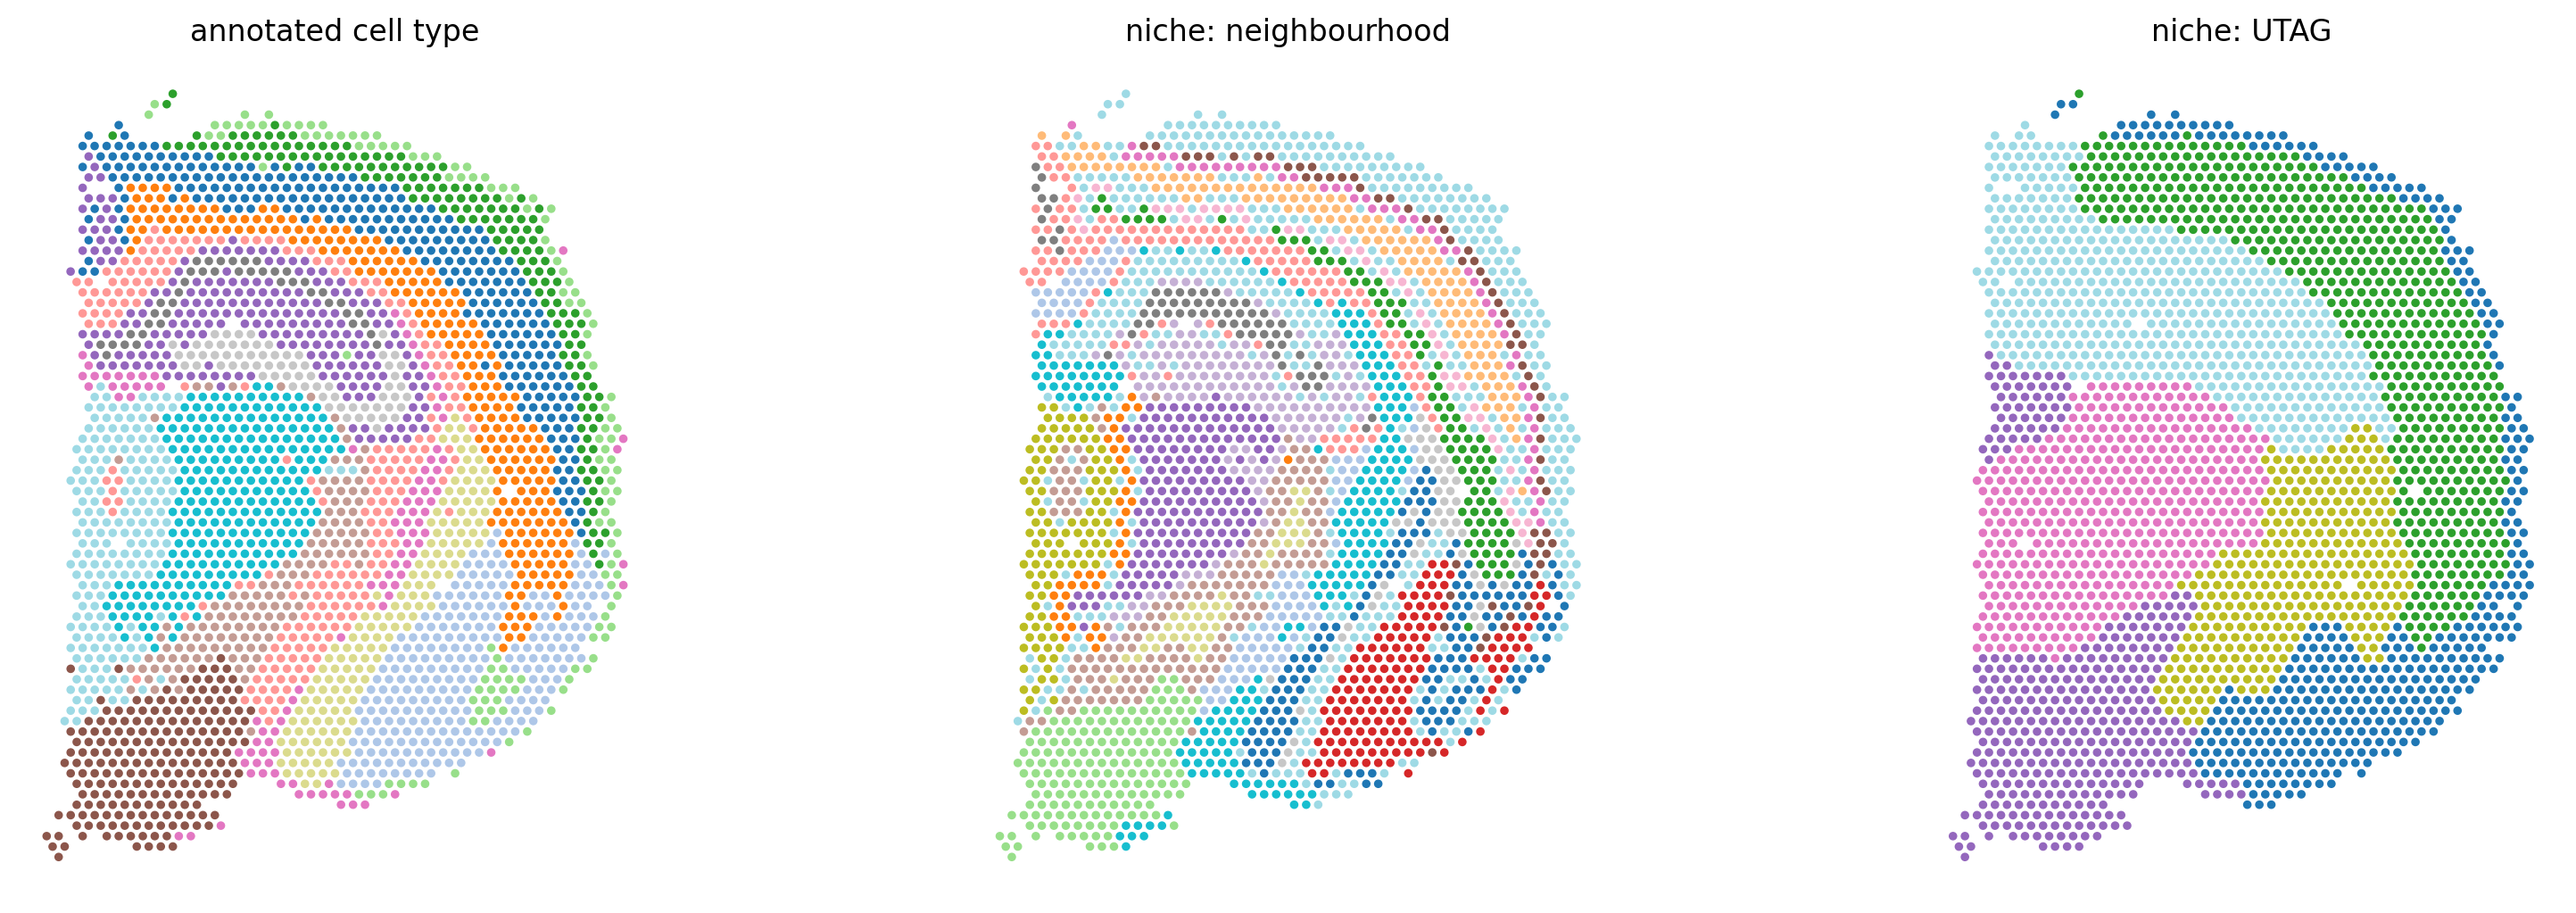

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
xy = adata.obsm['spatial']
for ax, key, title in zip(axes,
                          ['cell_type', 'niche_nb', 'niche_utag'],
                          ['annotated cell type', 'niche: neighbourhood', 'niche: UTAG']):
    codes = adata.obs[key].cat.codes
    ax.scatter(xy[:, 0], xy[:, 1], c=codes, s=6, cmap='tab20')
    ax.set_title(title); ax.set_aspect('equal'); ax.invert_yaxis(); ax.axis('off')
plt.show()

### Molecular niche — already in omicverse, under another name

The third flavour the issue asked for is the one from the myocardial-infarction and
pulmonary-fibrosis atlases: deconvolve each spot into cell-type abundances, then
factorise that matrix with NMF, and read each factor as a recurrent multicellular
programme.

omicverse has done this since `nmf_tissue_zones` shipped. `ov.space.niche.molecular`
is the same function under the name the literature uses — nobody looking for niche
analysis would search for "tissue zones".

It needs a per-spot cell-abundance matrix, which comes from
[`cell2location`](t_deconvolution.ipynb) or another deconvolution run, so it is not
executed here. The call is:

```python
zones = ov.space.niche.molecular(
    adata,                                  # carrying cell2location output
    obsm_key='q05_cell_abundance_w_sf',
    n_factors=10,
)
zones.plot_factor_loadings()
```

## Restricting any of this to a region

Every statistic above reads whichever graph it is given, so masking the graph is
how you restrict an analysis to one region without subsetting the object and
losing the surrounding context.

In [29]:
mid = xy.mean(axis=0)
region = [(xy[:, 0].min(), xy[:, 1].min()), (xy[:, 0].min(), mid[1]),
          (mid[0], mid[1]), (mid[0], xy[:, 1].min())]
ov.space.nb.mask(adata, region, key_added='roi')
print(f"{int(adata.obs['roi'].sum())} of {adata.n_obs} spots inside the region; "
      f"{adata.obsp['roi_connectivities'].nnz:,} of "
      f"{adata.obsp['spatial_connectivities'].nnz:,} edges kept")

666 of 2688 spots inside the region; 3,548 of 14,756 edges kept


In [30]:
region_z = ov.space.nb.enrichment(adata, 'cell_type', connectivity_key='roi_connectivities',
                                  n_perms=200, seed=0, copy=True)['zscore']
whole_z = adata.uns['cell_type_nhood_enrichment']['zscore']
m = np.isfinite(region_z) & np.isfinite(whole_z)
print(f"enrichment inside the region vs the whole slide: Pearson r = "
      f"{np.corrcoef(region_z[m], whole_z[m])[0, 1]:.3f}")

enrichment inside the region vs the whole slide: Pearson r = 0.684


## Splitting the slide into pseudo-replicates

`sliding_window` tiles the tissue, which turns one section into several and lets a
statistic be given an error bar — or shows that a result holds locally rather than
only over the slide as a whole.

In [31]:
ov.space.nb.sliding_window(adata, window_size=2000)
sizes = adata.obs['sliding_window_assignment'].value_counts()
print(f"{len(sizes)} windows, {sizes.min()}-{sizes.max()} spots each")

17 windows, 12-246 spots each


## Where the numbers come from

These statistics follow squidpy's definitions on purpose: each has one correct
definition, and matching a reference implementation is what makes the numbers
checkable rather than merely plausible. Measured against squidpy 1.6.5 on an
identical graph:

| | agreement |
|---|---|
| `interaction_matrix` | exact |
| `nhood_enrichment` counts | exact |
| `nhood_enrichment` z | Pearson r = 0.9975 (independent permutation draws) |
| `centrality` | exact |
| `co_occurrence` | Pearson r = 1.0000 |
| `ripley` F / G / L | Pearson r = 1.0000 each |
| `sepal` | Spearman rho = 0.864 |
| `sliding_window` | ARI = 1.0000 |
| `var_by_distance` | max abs. difference 1.11e-16 |

Four of them needed a rewrite to get there. Centrality is a group centrality over
the whole graph, not a property of each cluster's induced subgraph. Co-occurrence
takes its marginal from the pairs inside the radius, not from global cluster
frequencies. Ripley's G measures inwards from spots *outside* the cluster, and L
takes its intensity from all observations over the convex-hull area. Each of those
mistakes would have produced a plausible number that was not the statistic it
claimed to be.